In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/final_dataset.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")

In [2]:
import numpy as np

# time features
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

In [3]:
df["lag_24"] = df["price"].shift(24)
df["lag_48"] = df["price"].shift(48)
df["lag_168"] = df["price"].shift(168)

In [4]:
df["rolling_mean_24"] = df["price"].shift(1).rolling(24).mean()
df["rolling_std_24"] = df["price"].shift(1).rolling(24).std()

In [6]:
df = df.dropna()
df.head()

,price,load,wind,solar,hour,dayofweek,month,hour_sin,hour_cos,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24
timestamp,,,,,,,,,,,,,,
2023-01-08 00:00:00,10.93,42509.00,32706.50,2.00,0,6,1,0.000000,1.000000,97.15,107.21,-5.17,88.808750,17.158858
2023-01-08 01:00:00,9.07,40708.50,31837.25,2.00,1,6,1,0.258819,0.965926,98.43,101.10,-1.07,85.216250,23.273035
2023-01-08 02:00:00,9.10,39829.75,30603.50,2.00,2,6,1,0.500000,0.866025,96.05,96.73,-1.47,81.492917,27.779032
2023-01-08 03:00:00,4.16,40059.50,28985.50,2.00,3,6,1,0.707107,0.707107,87.97,82.34,-5.08,77.870000,31.250968
2023-01-08 04:00:00,5.58,40147.00,28325.25,2.25,4,6,1,0.866025,0.500000,82.99,81.93,-4.49,74.377917,34.578714


In [7]:
train = df[: "2025-12-31"]
test = df["2026-01-01":]

In [8]:
features = [
    "hour", "dayofweek", "month",
    "hour_sin", "hour_cos",
    "lag_24", "lag_48", "lag_168",
    "rolling_mean_24", "rolling_std_24",
    "load", "wind", "solar"
]

In [9]:
from sklearn.linear_model import Ridge

X_train = train[features]
y_train = train["price"]

X_test = test[features]
y_test = test["price"]

model = Ridge()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error

mae_model = mean_absolute_error(y_test, pred)
mae_baseline = mean_absolute_error(y_test, test["lag_24"])

print("Model MAE:", mae_model)
print("Baseline MAE:", mae_baseline)

Model MAE: 15.322494797870855
Baseline MAE: 22.043645833333336


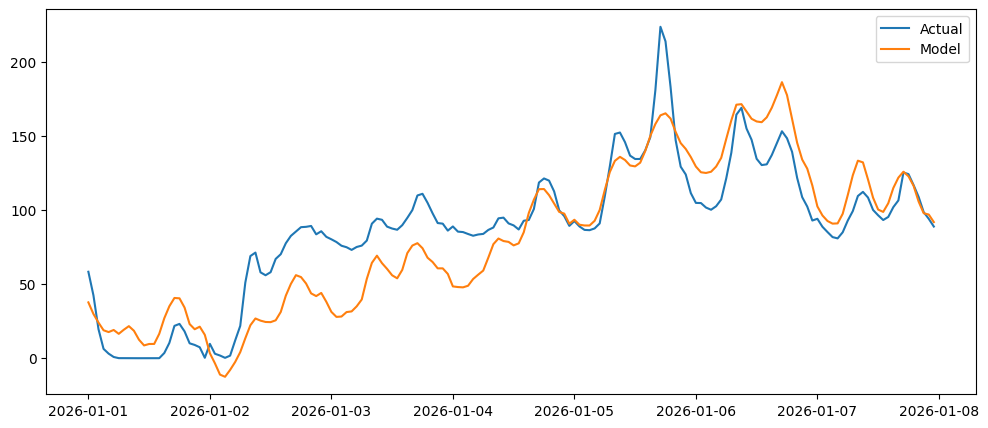

In [11]:
import matplotlib.pyplot as plt

sample = test["2026-01-01":"2026-01-07"]

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample["price"], label="Actual")
plt.plot(sample.index, pred[:len(sample)], label="Model")
plt.legend()
plt.show()

XGBoost Model

In [12]:
import pandas as pd

df = pd.read_csv("../data/processed/final_dataset.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")

In [13]:
import numpy as np

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["lag_24"] = df["price"].shift(24)
df["lag_48"] = df["price"].shift(48)
df["lag_168"] = df["price"].shift(168)

df["rolling_mean_24"] = df["price"].shift(1).rolling(24).mean()
df["rolling_std_24"] = df["price"].shift(1).rolling(24).std()

df = df.dropna()

In [14]:
train = df[: "2025-12-31"]
test = df["2026-01-01":]

In [15]:
features = [
    "hour", "dayofweek", "month",
    "hour_sin", "hour_cos",
    "lag_24", "lag_48", "lag_168",
    "rolling_mean_24", "rolling_std_24",
    "load", "wind", "solar"
]

X_train = train[features]
y_train = train["price"]

X_test = test[features]
y_test = test["price"]

In [16]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [17]:
pred = model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error

mae_xgb = mean_absolute_error(y_test, pred)
mae_baseline = mean_absolute_error(y_test, test["lag_24"])

print("XGBoost MAE:", mae_xgb)
print("Baseline MAE:", mae_baseline)

XGBoost MAE: 12.738980305228383
Baseline MAE: 22.043645833333336


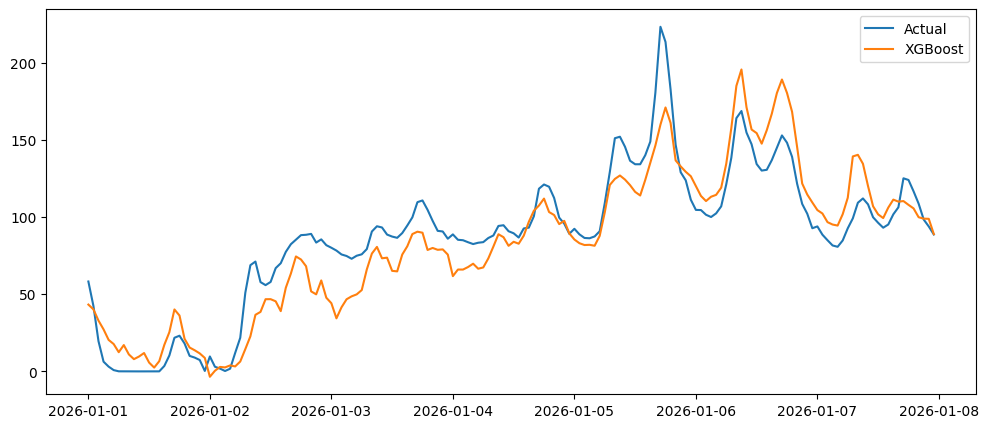

In [19]:
import matplotlib.pyplot as plt

sample = test["2026-01-01":"2026-01-07"]

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample["price"], label="Actual")
plt.plot(sample.index, pred[:len(sample)], label="XGBoost")
plt.legend()
plt.show()

In [21]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values(ascending=False)

lag_24             0.407833
wind               0.107453
solar              0.093750
lag_168            0.082944
rolling_mean_24    0.081205
load               0.063767
rolling_std_24     0.046776
dayofweek          0.028298
hour_sin           0.025539
lag_48             0.020209
hour               0.016230
hour_cos           0.015301
month              0.010693
dtype: float32

The model relies heavily on lag_24, indicating strong daily seasonality. However, wind and solar are among the most important external features, showing that renewable generation significantly impacts electricity prices. This confirms that incorporating supply-side variables improves forecasting performance beyond using historical prices alone.

XGBoost Improvement: Additional Features and Tuning 

In [49]:
df["rolling_mean_48"] = df["price"].shift(1).rolling(48).mean()
df["rolling_mean_168"] = df["price"].shift(1).rolling(168).mean()

In [50]:
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

In [51]:
df = df.dropna()

df.head()

,price,load,wind,solar,hour,dayofweek,month,hour_sin,hour_cos,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24,lag_1,rolling_mean_48,rolling_mean_168,is_weekend
timestamp,,,,,,,,,,,,,,,,,,
2023-01-22 00:00:00,127.60,46953.25,20234.25,4.25,0,6,1,0.000000,1.000000,144.13,146.89,3.94,144.391667,15.521771,117.76,162.525625,126.942262,1
2023-01-22 01:00:00,119.01,45361.75,19701.75,4.25,1,6,1,0.258819,0.965926,140.06,144.50,1.71,143.702917,15.896117,127.60,162.123750,127.678333,1
2023-01-22 02:00:00,116.77,44649.00,18921.00,4.00,2,6,1,0.500000,0.866025,140.19,142.44,4.10,142.825833,16.667851,119.01,161.592708,128.376548,1
2023-01-22 03:00:00,118.35,44000.75,17696.75,4.50,3,6,1,0.707107,0.707107,133.74,142.80,2.65,141.850000,17.493976,116.77,161.057917,129.047202,1
2023-01-22 04:00:00,122.12,43980.50,16656.50,4.25,4,6,1,0.866025,0.500000,131.24,144.98,2.87,141.208750,18.076541,118.35,160.548542,129.735893,1


In [52]:
train = df[: "2025-12-31"]
test = df["2026-01-01":]

In [53]:
features = [
    "hour", "dayofweek", "month","is_weekend",
    "hour_sin", "hour_cos",
    "lag_24", "lag_48", "lag_168",
    "rolling_mean_24", "rolling_std_24", "rolling_mean_48", "rolling_mean_168",
    "load", "wind", "solar"
]

X_train = train[features]
y_train = train["price"]

X_test = test[features]
y_test = test["price"]

In [84]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.75,
    colsample_bytree=0.75,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.75
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [85]:
pred = model.predict(X_test)

In [86]:
from sklearn.metrics import mean_absolute_error

mae_xgb = mean_absolute_error(y_test, pred)
mae_baseline = mean_absolute_error(y_test, test["lag_24"])

print("XGBoost MAE:", mae_xgb)
print("Baseline MAE:", mae_baseline)

XGBoost MAE: 12.251845510487756
Baseline MAE: 22.043645833333336


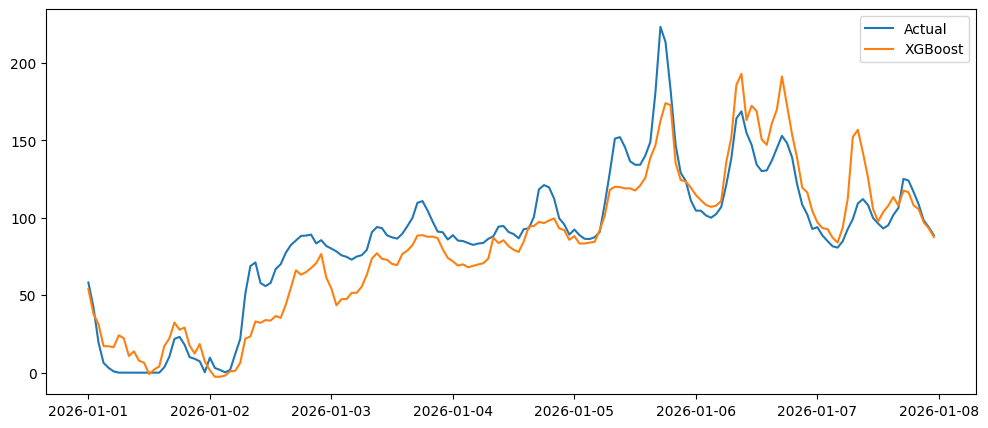

In [58]:
import matplotlib.pyplot as plt

sample = test["2026-01-01":"2026-01-07"]

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample["price"], label="Actual")
plt.plot(sample.index, pred[:len(sample)], label="XGBoost")
plt.legend()
plt.show()

Including lag_1 significantly reduced the error, but it introduces information leakage for multi-step forecasting, as future hourly values would not be available in a real prediction scenario. Therefore, lag_1 was excluded from the final model. on keeping lag_1 we get XGBoost MAE: 5.32453347288988.

In [88]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "objective": "reg:squarederror"
    }

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)

    return mae

In [89]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

[I 2026-04-28 19:27:40,467] A new study created in memory with name: no-name-27f7cb62-ebf6-4852-8946-df7740dbdfdf
[I 2026-04-28 19:27:43,757] Trial 0 finished with value: 13.126873241811989 and parameters: {'n_estimators': 381, 'learning_rate': 0.19629149102456137, 'max_depth': 8, 'subsample': 0.6761322987914139, 'colsample_bytree': 0.940013858438074}. Best is trial 0 with value: 13.126873241811989.
[I 2026-04-28 19:27:44,774] Trial 1 finished with value: 12.976072411090135 and parameters: {'n_estimators': 480, 'learning_rate': 0.06903856820062229, 'max_depth': 6, 'subsample': 0.9180527124169904, 'colsample_bytree': 0.9511303016981977}. Best is trial 1 with value: 12.976072411090135.
[I 2026-04-28 19:27:46,116] Trial 2 finished with value: 12.411413882672786 and parameters: {'n_estimators': 107, 'learning_rate': 0.043430943674531666, 'max_depth': 9, 'subsample': 0.7955264760083025, 'colsample_bytree': 0.8504892780639179}. Best is trial 2 with value: 12.411413882672786.
[I 2026-04-28 19

In [90]:
print("Best MAE:", study.best_value)
print("Best parameters:", study.best_params)

Best MAE: 11.895321540854871
Best parameters: {'n_estimators': 104, 'learning_rate': 0.1165142005359301, 'max_depth': 4, 'subsample': 0.8534870394701352, 'colsample_bytree': 0.919407329968692}


In [91]:
best_params = study.best_params

model_xgb_opt = XGBRegressor(
    **best_params,
    random_state=42,
    objective="reg:squarederror"
)

model_xgb_opt.fit(X_train, y_train)

pred_xgb_opt = model_xgb_opt.predict(X_test)

mae_xgb_opt = mean_absolute_error(y_test, pred_xgb_opt)

print("XGBoost Bayesian Optimized MAE:", mae_xgb_opt)

XGBoost Bayesian Optimized MAE: 11.895321540854871


| Model                | MAE   |
|---------------------|-------|
| Baseline (Lag 24)   | 22.04 |
| Ridge               | 20.09 |
| Ridge (With External Features)     | 15.32 |
| Prophet               | 26.84 |
| XGBoost (Basic)     | 12.72 |
| XGBoost (Feature + Manual tuning) | 12.25 |
| XGBoost (Bayesian Optimized)     | 11.89 |
